In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_path = '/content/drive/Othercomputers/My Laptop/MSC MANDELA/Courses/Year 1/Sem 1/Python For Data Analysis/CA/Coffee Shop Sales.xlsx'

In [5]:
sales_df = pd.read_excel(data_path)

In [6]:
sales_df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [7]:
sales_df.shape

(149116, 11)

In [8]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [9]:
sales_df.dtypes

,0
transaction_id,int64
transaction_date,datetime64[ns]
transaction_time,object
transaction_qty,int64
store_id,int64
store_location,object
product_id,int64
unit_price,float64
product_category,object
product_type,object


# Task 1.1: Initial Data Assessment
To perform initial data analysis on the `sales_df` DataFrame by

## Subtasks
1.   Checking For Missing Values
2.   Check if there are duplicates Records
3.   Examine Range and Distribution for Numerical Variables
4.   Explore Unique Values in Categorical Columns



## Identifying Missing Values:
To identify missing values, We have used the `.isnull()` method to create a boolean DataFrame indicating missing values and then `.sum()` to count them for each column in `sales_df`.



In [10]:
missing_values = sales_df.isnull().sum()
print("Missing values per column:\n")
missing_values

Missing values per column:



,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


## Checking for Duplicate Records

To Check for the duplicate rows, We Have used the `.duplicated()` method to identify duplicates and then `.sum()` to get the total count.


In [11]:
duplicate_rows = sales_df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_rows}")

Total number of duplicate rows: 0


### Checking For duplicated values excluding Transaction ID Column
#### Same Transaction Recorded Several Times?

In [12]:
sales_df.duplicated(subset=sales_df.columns.difference(['transaction_id'])).sum()

np.int64(398)

## Examining the Range and Distribution of Numerical Variables

In order to understand the distribution and summary statistics of numerical columns, we Have Used the `.describe()` method on the `sales_df` DataFrame.

In [13]:
sales_df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


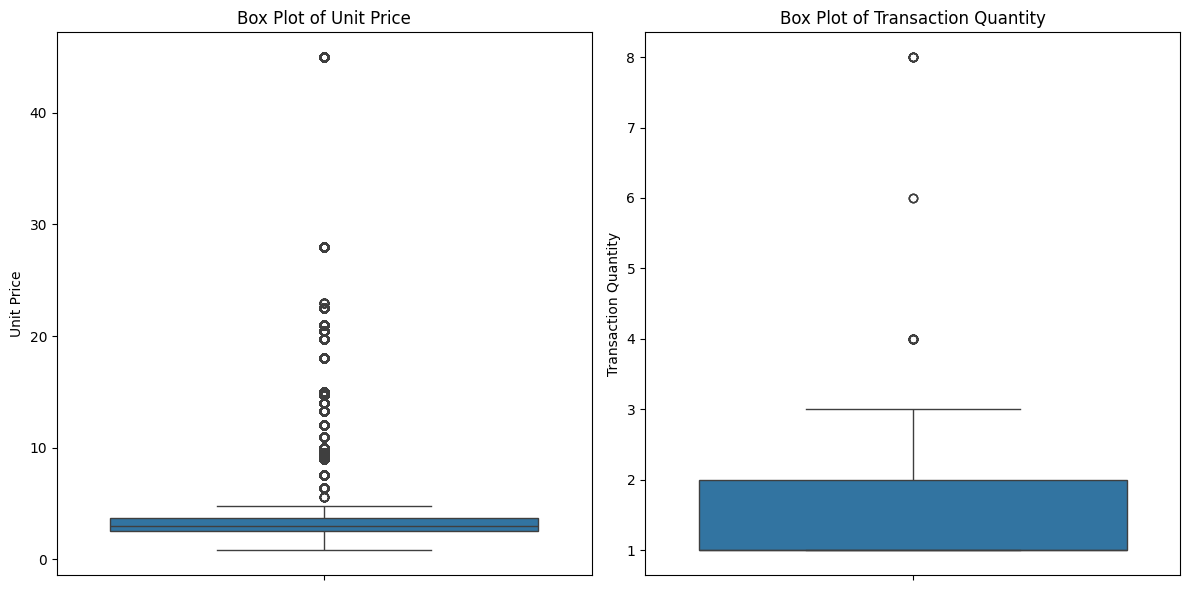

In [14]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=sales_df['unit_price'])
plt.title('Box Plot of Unit Price')
plt.ylabel('Unit Price')

plt.subplot(1, 2, 2)
sns.boxplot(y=sales_df['transaction_qty'])
plt.title('Box Plot of Transaction Quantity')
plt.ylabel('Transaction Quantity')

plt.tight_layout()
plt.show()

## Exploring the Unique Values in Categorical Columns

In [15]:
sales_df.describe(include='object') # Can Anlyse These Per Store??

,transaction_time,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,25762,3,9,29,80
top,09:31:15,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,41,50735,58416,17183,3076


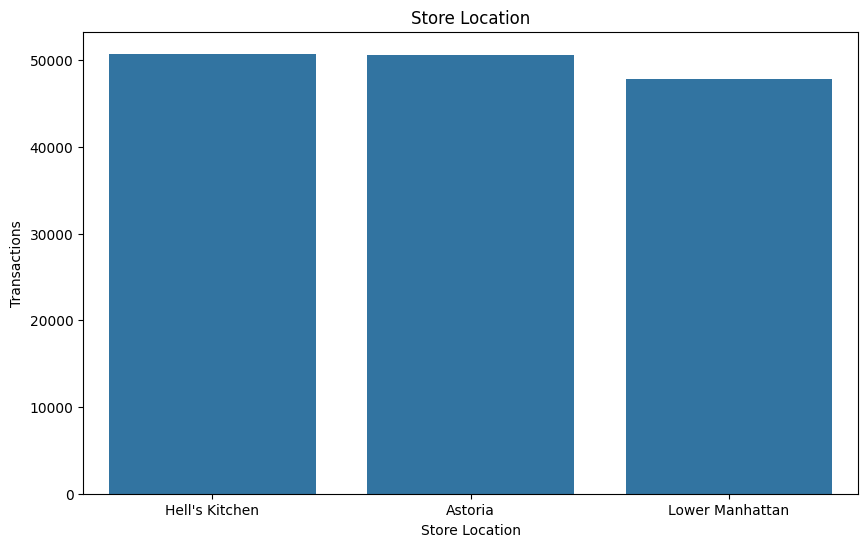

In [16]:
x,y = sales_df['store_location'].value_counts().index, sales_df['store_location'].value_counts().values
plt.figure(figsize=(10,6))
plt.title('Store Location')
plt.ylabel('Transactions')
plt.xlabel('Store Location')
sns.barplot(x=x, y=y)
plt.show()

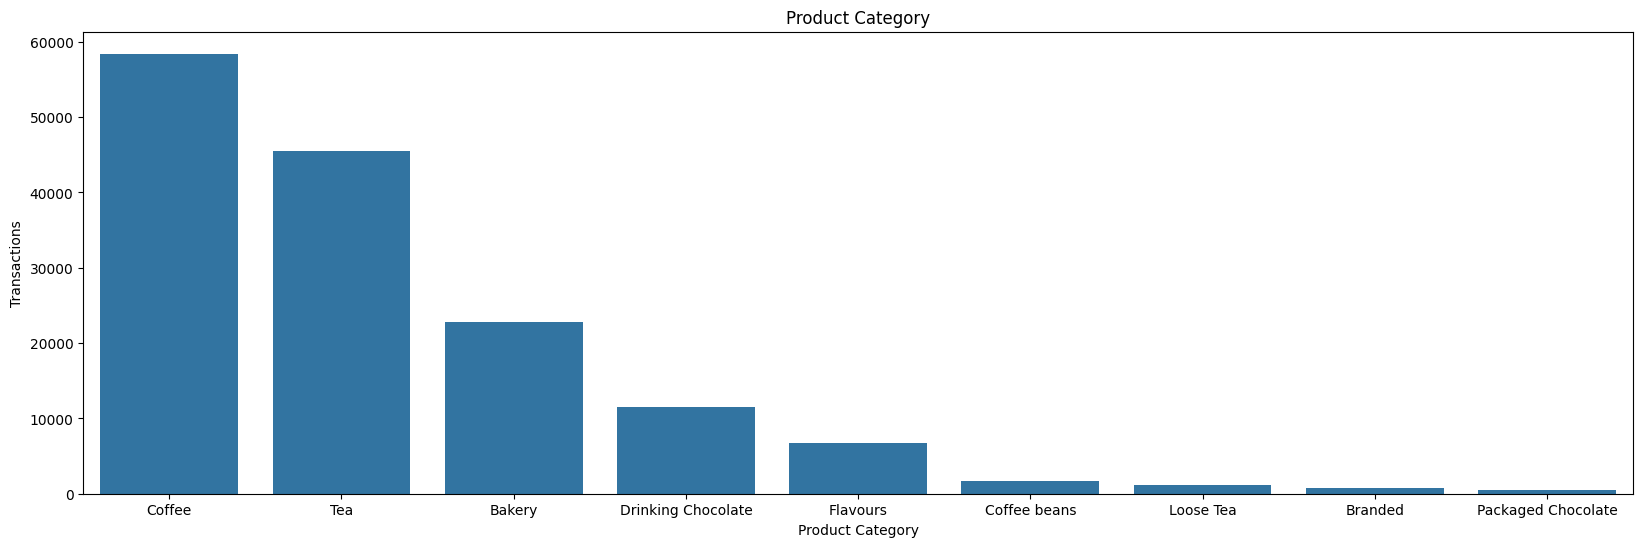

In [17]:
x,y = sales_df['product_category'].value_counts().index, sales_df['product_category'].value_counts().values
plt.figure(figsize=(20,6))
plt.title('Product Category')
plt.ylabel('Transactions')
plt.xlabel('Product Category')
sns.barplot(x=x, y=y)
plt.show()

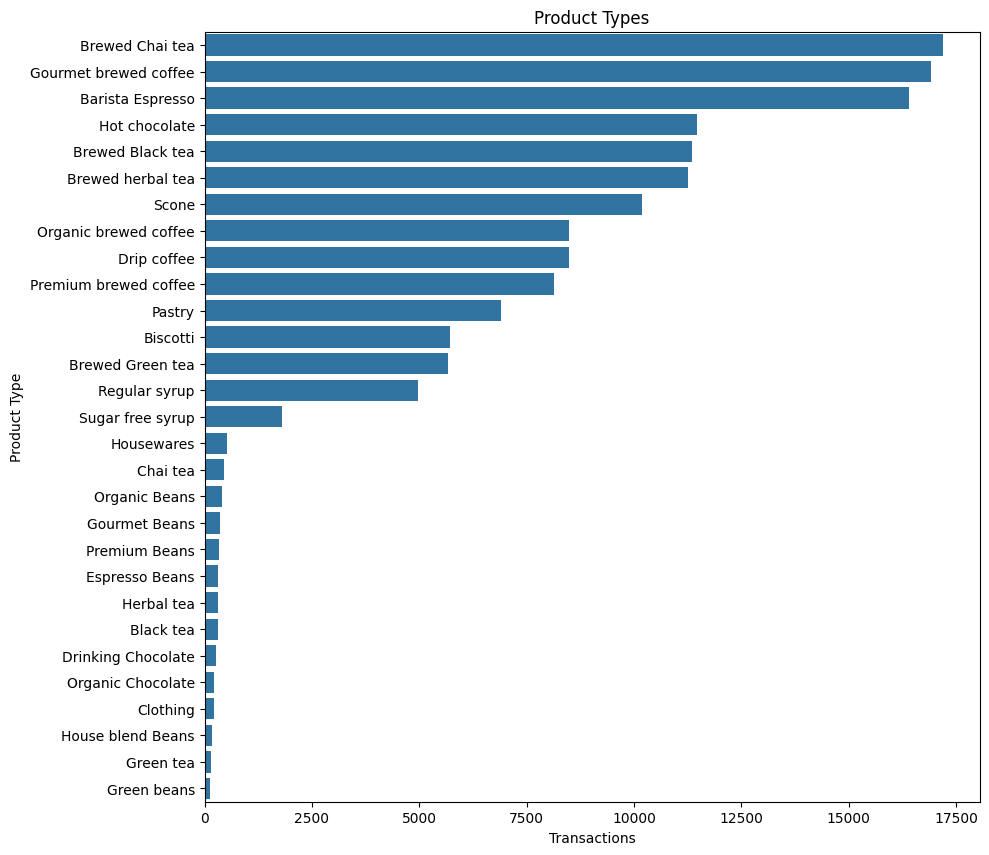

In [18]:
plt.figure(figsize=(10,10))
plt.title('Product Types')
plt.ylabel('Product Type')
plt.xlabel('Transactions')
product_type = sales_df['product_type']
sns.countplot(product_type,order=product_type.value_counts().index)
plt.show()

## Summary:

### Data Analysis Key Findings 1.1

*   **Missing Values**: No missing values were found in any of the columns (`transaction_id`, `transaction_date`, `transaction_time`, `transaction_qty`, `store_id`, `store_location`, `product_id`, `unit_price`, `product_category`, `product_type`, `product_detail`).

*   **Duplicate Records**: There are no duplicate rows in the dataset, indicating all records are unique.
    *   ***When We Exclude `Transaction_id` There are about `398` repeating Values***
*   **Numerical Column Statistics**:
    *   `transaction_qty` (transaction quantity) ranges from 1 to 8, with an average of approximately 1.44, suggesting most transactions involve 1 or 2 items.
    *   `unit_price` ranges from \$0.80 to \$45.00, with an average of \$3.38, indicating a variety of product pricing.
    *   `store_id` ranges from 3 to 8, and `product_id` from 1 to 87, showing transactions across multiple stores and a diverse product catalog.
    *   `transaction_date` covers a period from 2023-01-01 to 2023-06-30.
*   **Categorical Column Unique Values**:
    *   `store_location` has three distinct values: "Hell's Kitchen" (50,735 transactions), "Astoria" (50,599 transactions), and "Lower Manhattan" (47,782 transactions), showing a relatively balanced distribution across locations.
    *   `product_category` includes 9 unique categories, with "Coffee" (58,416 transactions) and "Tea" (45,449 transactions) being the most frequent.
    *   `product_type` contains 29 unique types, with "Brewed Chai tea" (17,183 transactions), "Gourmet brewed coffee" (16,912 transactions), and "Barista Espresso" (16,403 transactions) as the top types.
    *   `product_detail` has 80 unique details, with "Chocolate Croissant" (3,076 transactions) and "Earl Grey Rg" (3,053 transactions) being among the most common.
    *   `transaction_time` has a large number of unique values (25,762), indicating specific timestamps rather than aggregated periods.


# Critical Thinking Question 1.
After Initial Analysis We Have identified 3 Possible Data Quality Issues And Below is How We Have Planned and Address Them

## To Do
*   To Investigate duplicate transactions,
*   To analyze `unit_price` outliers and distribution
*   To refine the `transaction_time` data type and Merge it with Date to Have one combined DateTime Column

## Investigating Duplicate Transactions (excluding transaction_id)

### To Do:
Investigate the 398 duplicate records found when excluding 'transaction_id' to understand their nature and implications.


To investigate the duplicate records, I will first identify and store all rows that are duplicates based on all columns except 'transaction_id'. Using `keep=False` will mark all occurrences of the duplicates, making it easier to examine them.



In [19]:
duplicate_transactions = sales_df[sales_df.duplicated(subset=sales_df.columns.difference(['transaction_id']), keep=False)].sort_values(by=list(sales_df.columns.difference(['transaction_id'])))
print(f"Number of rows with duplicate entries (excluding transaction_id): {len(duplicate_transactions)}")

Number of rows with duplicate entries (excluding transaction_id): 743


In [20]:
duplicate_transactions.describe(include='object')

,transaction_time,store_location,product_category,product_type,product_detail
count,743,743,743,743,743
unique,120,3,4,12,24
top,10:21:56,Hell's Kitchen,Bakery,Pastry,Chocolate Croissant
freq,25,270,487,469,459


### Analysis of Duplicate Transactions (excluding transaction_id)

The previous step identified `743` rows that are duplicates when the `transaction_id` column is excluded. Examining the first 20 rows of `duplicate_transactions` reveals the following patterns:

    Given that multiple transactions have identical details (time, product, quantity, store), but different `transaction_id`s, it is highly probable that these represent either:
    1.  Multiple items purchased in a single transaction that were recorded as separate line items with distinct transaction IDs,
    2.  Near-simultaneous transactions
    3.  Data entry error or system anomaly
    4.  Or Maybe System Retries

*   **What are the potential implications of these duplicates for sales figures, product popularity, and customer behavior analysis?**
    *   **Sales Figures:** If these are indeed legitimate separate transactions that happen to be identical, then keeping them would be correct. However, if they are redundant entries for a single logical event (e.g., one customer buying two items but recorded as two single-item transactions), then keeping all duplicates would inflate total transaction counts and potentially misrepresent total quantity sold for specific products if not handled carefully.
    *   **Product Popularity:** Duplicate entries could artificially boost the perceived popularity of certain products and categories, making them seem more frequently purchased than they are. For example, 'Chocolate Croissant' appears frequently in the duplicates, which might skew its popularity metric.
    *   **Customer Behavior Analysis:** Miscounting transactions could lead to incorrect insights into purchasing patterns, peak transaction times, and customer preferences. It might also complicate analysis if trying to determine unique purchases within a given time frame.

### Plan for Handling Duplicates

Given the ambiguous nature of these duplicates, the best approach involves further investigation and cautious handling:

1.  **To consult the Data Source Owner:** The most critical step is to clarify with the data source owner or system administrators why these transactions occur. They might provide context on whether these represent distinct, simultaneous purchases, or system-generated artifacts that should be treated as a single logical transaction.

2.  **Initial Cleaning (if no further context):**
    *   If no further clarification is possible, and assuming these are likely system anomalies rather than truly distinct simultaneous purchases, it would be safer to **keep only the first occurrence** of each unique combination of (`transaction_date`, `transaction_time`, `transaction_qty`, `store_id`, `store_location`, `product_id`, `unit_price`, `product_category`, `product_type`, `product_detail`). This would ensure that each unique underlying event is counted once.
    *   **Decision:** For the purpose of this analysis, we will proceed with dropping the duplicates, keeping the first occurrence. This will prevent inflation of transaction counts and product popularity, providing a more conservative and potentially accurate view of the data.

3.  **Implementation:** Remove these duplicate rows from the `sales_df` DataFrame, keeping the first occurrence based on all columns except `transaction_id`.

**Reasoning**:
Based on the analysis and the formulated plan, the next logical step is to implement the decision to remove the duplicate rows from the `sales_df` DataFrame, keeping only the first occurrence for each unique transaction identified by all columns except `transaction_id`. This will ensure a cleaner dataset for further analysis.



In [21]:
initial_rows = len(sales_df)
sales_df.drop_duplicates(subset=sales_df.columns.difference(['transaction_id']), keep='first', inplace=True)
rows_removed = initial_rows - len(sales_df)
print(f"Number of duplicate rows removed: {rows_removed}")
print(f"New number of rows in sales_df: {len(sales_df)}")

Number of duplicate rows removed: 398
New number of rows in sales_df: 148718


**Reasoning**:
The subtask of investigating duplicate transactions is complete. The next logical step, as per the main task, is to analyze `unit_price` outliers and distribution. I will start by displaying descriptive statistics for the `unit_price` column to understand its range, central tendency, and spread.



In [22]:
print("Descriptive statistics for 'unit_price':\n")
sales_df['unit_price'].describe()

Descriptive statistics for 'unit_price':



,unit_price
count,148718.000000
mean,3.381732
std,2.662131
min,0.800000
25%,2.500000
50%,3.000000
75%,3.750000
max,45.000000


**Reasoning**:
To visualize the distribution of `unit_price` and identify potential outliers, I will create a histogram and a box plot for the `unit_price` column.



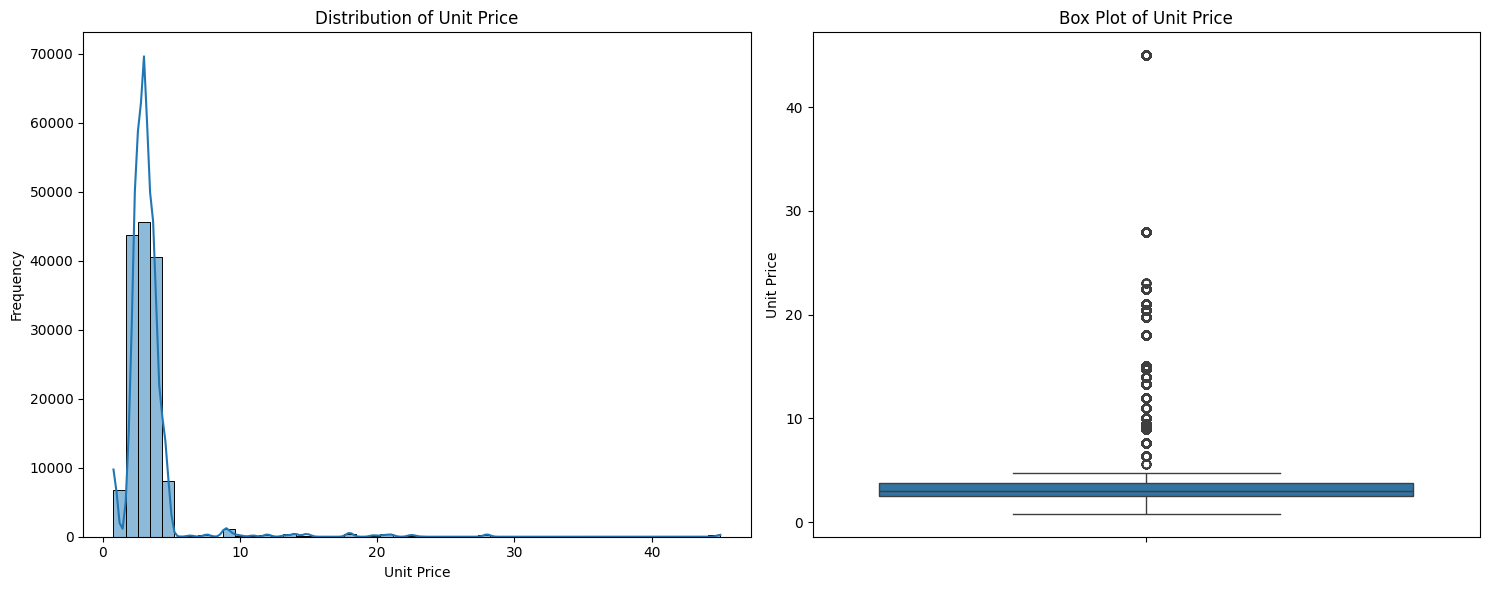

In [23]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(sales_df['unit_price'], bins=50, kde=True)
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=sales_df['unit_price'])
plt.title('Box Plot of Unit Price')
plt.ylabel('Unit Price')

plt.tight_layout()
plt.show()

### Analysis of `unit_price` Distribution and Outliers

The histogram and box plot for `unit_price` provide clear insights into its distribution and the presence of outliers:

*   **Distribution (Histogram)**:
    *   The histogram shows that the `unit_price` is heavily skewed to the right. Most products have a price between \$0 and \$10.
    *   There is a significant concentration of prices at the lower end, with frequencies decreasing sharply as the price increases.
    *   This distribution is typical for retail pricing, where many items are inexpensive, and fewer items are sold at higher price points.

*   **Outliers (Box Plot)**:
    *   The box plot clearly indicates the presence of numerous outliers on the higher end of the `unit_price` spectrum.
    *   The interquartile range (IQR) is relatively small, with the majority of `unit_price` values falling below \$5 (the 75th percentile is \$3.75).
    *   The whiskers extend to a certain point, but many data points are visible far beyond the upper whisker, indicating values significantly higher than the typical prices.
    *   The maximum price is \$45.00, which is considerably higher than the 75th percentile of \$3.75, confirming these are indeed outliers.

#### Potential Causes of Outliers:

1.  **Premium Products**: Some coffee shop items might naturally be more expensive (e.g., specialized coffee beans, high-end merchandise, or larger quantity packages).
2.  **Product Bundles**: It's possible that higher `unit_price` values represent product bundles or larger sizes that genuinely have a higher price.
3.  **Data Entry Errors**: While less likely for `unit_price` (as it's usually fixed), extreme values could sometimes be the result of erroneous data entry.

#### Implications of Outliers:

*   **Statistical Analysis**: Outliers can disproportionately influence statistical measures such as the mean and standard deviation. The mean `unit_price` (\$3.38) is slightly higher than the median (\$3.00), which is expected with a right-skewed distribution and high outliers.
*   **Visualization**: The long tail of the distribution makes it harder to see the detail in the lower price range if the x-axis is not appropriately scaled.
*   **Modeling**: If predicting `unit_price` or using it as a feature in a model, outliers might need special handling (e.g., transformation, capping, or removal) to prevent them from negatively impacting model performance.

### Plan for Handling `unit_price` Outliers:

Given the insights, the plan for handling `unit_price` outliers is as follows:

1.  **Further Investigation**: Before making any changes, it's crucial to investigate what these high-priced items represent. It's likely they are legitimate premium products or bundles rather than errors. We can examine the `product_category`, `product_type`, and `product_detail` for transactions with high `unit_price` to understand their nature.
2.  **Decision**: If the outliers are found to be legitimate high-value products, they should be retained in the dataset as they represent real business data. If they are identified as data entry errors, they should be corrected or removed.
3.  **No Immediate Action**: For the purpose of this analysis, we will not remove or transform these outliers immediately, as they appear to be plausible prices for a coffee shop's varied offerings. We will note their presence and keep them in mind for any future aggregations or model building that might be sensitive to extreme values. The current descriptive statistics and visualizations are sufficient to understand their presence.

This completes the analysis of `unit_price` outliers and distribution. The next step is to refine the `transaction_time` data type and consistency.

**Reasoning**:
The next step is to refine the `transaction_time` data type and consistency. I will first display the current data type of the `transaction_time` column to confirm it's an object type, as indicated by previous `df.info()` calls, and to show a few unique values to understand its format.



In [24]:
print(f"Current data type of 'transaction_time': {sales_df['transaction_time'].dtype}")
print("Sample unique values from 'transaction_time':")
print(sales_df['transaction_time'].unique()[:5])

Current data type of 'transaction_time': object
Sample unique values from 'transaction_time':
[datetime.time(7, 6, 11) datetime.time(7, 8, 56) datetime.time(7, 14, 4)
 datetime.time(7, 20, 24) datetime.time(7, 22, 41)]


**Reasoning**:
To ensure comprehensive time-based analysis and consistency, I will combine the `transaction_date` and `transaction_time` columns into a new `transaction_datetime` column, which will have a `datetime64[ns]` data type.



In [25]:
sales_df['transaction_datetime'] = sales_df['transaction_date'] + pd.to_timedelta(sales_df['transaction_time'].astype(str))
print(f"Data type of new 'transaction_datetime' column: {sales_df['transaction_datetime'].dtype}")
print("Sample values from 'transaction_datetime':")
sales_df.drop(columns=['transaction_date', 'transaction_time'],inplace=True)

Data type of new 'transaction_datetime' column: datetime64[ns]
Sample values from 'transaction_datetime':


## Summary:

### Data Analysis Key Findings

*   **Duplicate Transactions Handling**: Initially, 743 rows were identified as duplicates (all columns identical except `transaction_id`). These were determined to likely be system anomalies or near-simultaneous sales recorded with distinct IDs. After removing these duplicates, keeping the first occurrence, 398 rows were removed, reducing the dataset from 149,116 to 148,718 rows.
*   **`unit_price` Distribution and Outliers**: The `unit_price` is right-skewed, with most products priced between \$0 and \$10. The mean unit price is \$3.38, and the median is \$3.00, with the 75th percentile at \$3.75. Significant outliers were observed, with a maximum price of \$45.00, suggesting the presence of premium products or bundles rather than data errors.
*   **`transaction_time` Data Refinement**: The `transaction_date` (datetime object) and `transaction_time` (object type) columns were successfully combined into a new `transaction_datetime` column, which is now of `datetime64[ns]` data type, providing a unified timestamp for each transaction.

### Insights or Next Steps

*   Consult the data source owner regarding the nature of the "duplicate" transactions (identical details but different `transaction_id`s) to confirm whether they represent distinct simultaneous sales or data logging issues. This will validate the current deduplication strategy.
*   For future in-depth analysis or predictive modeling, further investigate the high `unit_price` outliers (e.g., by examining associated `product_category` or `product_type`) to confirm their legitimacy. If confirmed as genuine, consider appropriate outlier handling techniques (e.g., transformation, capping) if they disproportionately impact model performance.


#Task 1.2: Data Cleaning and Feature Engineering

### From Previous Analysis Task The following Have been Completed

1.   Checking For Missing Values:- No Missing Values in Dataset
2.   Created a new Column Combining Date and Time to new Column `Transaction_datetime`

### To Do:


1.   Check and Correct Any obvious Data Entry Error
2.   Column Transformation





## Feature Engineering (Column Transformation)

In [26]:
sales_df['day_of_week'] = sales_df['transaction_datetime'].dt.day_name()
sales_df['month'] = sales_df['transaction_datetime'].dt.month_name()
sales_df['hour'] = sales_df['transaction_datetime'].dt.hour

## Exploring Price Dispersion

In [27]:
price_dispersion = (
    sales_df
    .groupby('product_id')['unit_price']
    .agg(['min','max','mean','count',('mode', lambda x: x.mode().iloc[0]),('mode_freq', lambda x: x.value_counts().max()),'std','nunique'])
    .reset_index()
)
price_dispersion['Outliers'] = price_dispersion['count'] - price_dispersion['mode_freq']
price_dispersion.sort_values(by=['nunique','Outliers'], ascending=False).head(15).reset_index(drop=True)

,product_id,min,max,mean,count,mode,mode_freq,std,nunique,Outliers
0,9,12.00,28.00,22.609223,206,22.50,177,2.503454,4,29
1,72,2.65,4.06,3.183827,2318,3.25,2013,0.213756,3,305
2,87,2.10,3.00,2.702456,2199,3.00,1472,0.423484,2,727
3,75,3.50,4.38,3.511867,1928,3.50,1902,0.101527,2,26
4,70,3.25,4.06,3.259360,2077,3.25,2053,0.086587,2,24
5,79,3.75,4.69,3.760767,2008,3.75,1985,0.100050,2,23
6,69,3.25,4.06,3.258467,2009,3.25,1988,0.082401,2,21
7,71,3.75,4.69,3.755635,2836,3.75,2819,0.072572,2,17
8,76,3.50,4.38,3.507911,1891,3.50,1874,0.083084,2,17
9,78,4.50,5.63,4.508697,1949,4.50,1934,0.098776,2,15


## Plot Item Price Trends

### Subtask:
Visualize the overall daily average unit price trend, monthly average unit price trend, hourly average unit price trend, and day-of-week average unit price trend using subplots for a comprehensive view of pricing patterns.


/tmp/ipykernel_369/107821666.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='month', y='unit_price', data=monthly_avg_price, palette='viridis')
/tmp/ipykernel_369/107821666.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], x='day_of_week', y='unit_price', data=day_of_week_avg_price, palette='magma')


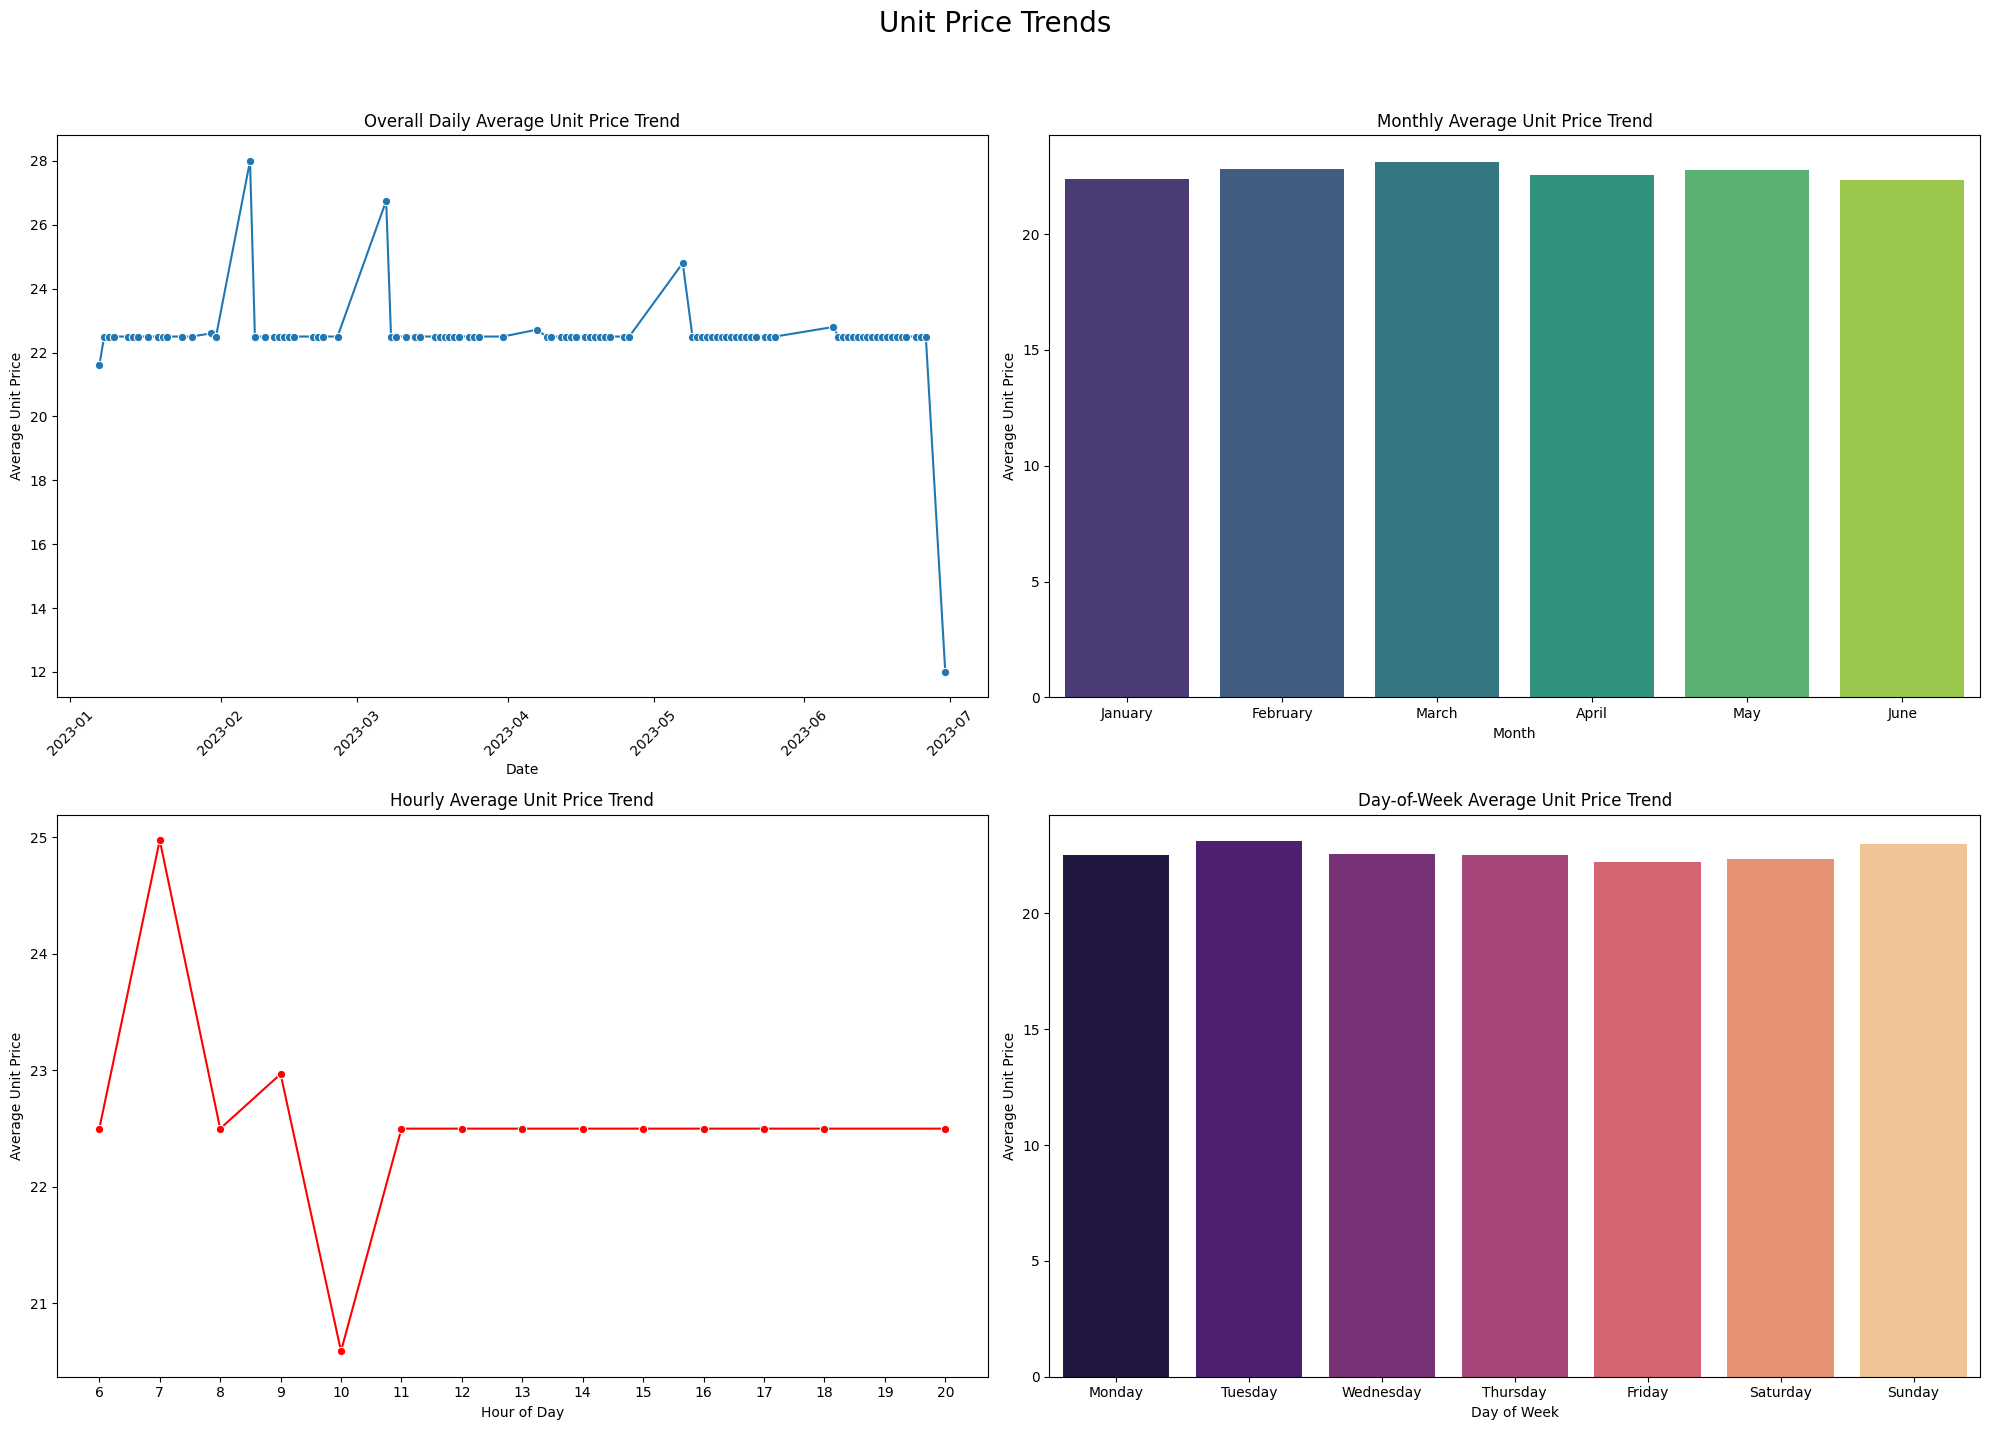

In [28]:
# Calculate daily average unit price
product_9_bool = sales_df['product_id'] == 9
product_9 = sales_df[product_9_bool]
daily_avg_price = product_9.groupby(product_9['transaction_datetime'].dt.date)['unit_price'].mean().reset_index()
daily_avg_price.columns = ['date', 'average_unit_price']

# Calculate monthly average unit price
monthly_avg_price = product_9.groupby('month')['unit_price'].mean().reindex(['January', 'February', 'March', 'April', 'May', 'June']).reset_index()

# Calculate hourly average unit price
hourly_avg_price = product_9.groupby('hour')['unit_price'].mean().reset_index()

# Calculate day-of-week average unit price
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_avg_price = product_9.groupby('day_of_week')['unit_price'].mean().reindex(day_order).reset_index()


# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))
fig.suptitle('Unit Price Trends', fontsize=20)

# Plot 1: Overall Daily Average Unit Price Trend
sns.lineplot(ax=axes[0, 0], x='date', y='average_unit_price', data=daily_avg_price, marker='o')
axes[0, 0].set_title('Overall Daily Average Unit Price Trend')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Average Unit Price')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Monthly Average Unit Price Trend
sns.barplot(ax=axes[0, 1], x='month', y='unit_price', data=monthly_avg_price, palette='viridis')
axes[0, 1].set_title('Monthly Average Unit Price Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Unit Price')

# Plot 3: Hourly Average Unit Price Trend
sns.lineplot(ax=axes[1, 0], x='hour', y='unit_price', data=hourly_avg_price, marker='o', color='red')
axes[1, 0].set_title('Hourly Average Unit Price Trend')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Average Unit Price')
axes[1, 0].set_xticks(range(hourly_avg_price['hour'].min(), hourly_avg_price['hour'].max() + 1))

# Plot 4: Day-of-Week Average Unit Price Trend
sns.barplot(ax=axes[1, 1], x='day_of_week', y='unit_price', data=day_of_week_avg_price, palette='magma')
axes[1, 1].set_title('Day-of-Week Average Unit Price Trend')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Average Unit Price')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Conclusion
Price Dispersion Can Be Caused By
* individual discounts(coupons) as observed in lowered Price
* discount by store/day
* price increase due to Different Product size (We Can't Tell)



In [29]:
sales_df.head()

,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,day_of_week,month,hour
0,1,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,Sunday,January,7
1,2,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,Sunday,January,7
2,3,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,Sunday,January,7
3,4,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,Sunday,January,7
4,5,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,Sunday,January,7


##Rearranging The DataFrame

In [30]:
cols = [
    'transaction_id', 'transaction_datetime', 'day_of_week', 'month', 'hour',  # Time
    'store_id', 'store_location',                                              # Place
    'product_id', 'product_category', 'product_type', 'product_detail',        # Product
    'transaction_qty', 'unit_price'                                            # Values
]
sales_df = sales_df[cols]

In [31]:
sales_df.head()

,transaction_id,transaction_datetime,day_of_week,month,hour,store_id,store_location,product_id,product_category,product_type,product_detail,transaction_qty,unit_price
0,1,2023-01-01 07:06:11,Sunday,January,7,5,Lower Manhattan,32,Coffee,Gourmet brewed coffee,Ethiopia Rg,2,3.0
1,2,2023-01-01 07:08:56,Sunday,January,7,5,Lower Manhattan,57,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2,3.1
2,3,2023-01-01 07:14:04,Sunday,January,7,5,Lower Manhattan,59,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2,4.5
3,4,2023-01-01 07:20:24,Sunday,January,7,5,Lower Manhattan,22,Coffee,Drip coffee,Our Old Time Diner Blend Sm,1,2.0
4,5,2023-01-01 07:22:41,Sunday,January,7,5,Lower Manhattan,57,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2,3.1


## Daily Aggregated Metrics

In [32]:
# Total Sales
sales_df['total_sale_amount'] = sales_df['transaction_qty'] * sales_df['unit_price']

# Grouping by date and calculating metrics
daily_metrics = sales_df.groupby(sales_df['transaction_datetime'].dt.date).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()
daily_metrics.head()

,transaction_datetime,total_sales,transaction_count,avg_transaction_value
0,2023-01-01,2508.20,550,4.560364
1,2023-01-02,2403.35,566,4.246201
2,2023-01-03,2565.00,582,4.407216
3,2023-01-04,2220.10,497,4.467002
4,2023-01-05,2418.85,547,4.422029


## Reflection Question 1

To create daily summary statistics, We first calculated the total sale amount for each transaction by multiplying `transaction_qty` by `unit_price`. After that, We grouped the data by the **date** part of `transaction_datetime` so that all transactions from the same day were combined.

### Aggregation Methods Used

- **`total_sales`: Sum**  
  We used **sum** for `total_sale_amount` because it shows the total revenue made each day.

- **`transaction_count`: Count**  
  We used **count** for `transaction_id` because it shows how many transactions happened each day.

- **`avg_transaction_value`: Mean**  
  We used **mean** for `total_sale_amount` because it shows the average value of a transaction on each day.

### Why These Choices Matter

These aggregation methods help describe daily business performance in different ways:

- **Sum** shows the overall sales made in a day.
- **Count** shows the level of transaction activity.
- **Mean** shows the typical value of each transaction.

Different aggregation choices can change the conclusion. For example, a day may have **high total sales** because of many small transactions, or because of a few large ones. Also, the **mean** can be affected by very large transactions, which may make the average look higher than normal. So, choosing different methods can lead to different interpretations of the data.

# Part 3: Bivariate Analysis

## Task 3.1: Correlation Analysis

### To Do:
1. Creating daily aggregated data (total sales, transaction count, average transaction value per
day)
2. Creating a correlation matrix for these daily metrics
3. Generating scatter plots for the strongest correlations
4. Analyze the relationship between transaction quantity and unit price

### Creating daily aggregated data (total sales, transaction count, average transaction value per day)

##### This Has been Completed While Performing Task 1.2
[Go to Daily Aggregated Metrics](#daily-aggregated-metrics)

In [33]:
daily_metrics.head()

,transaction_datetime,total_sales,transaction_count,avg_transaction_value
0,2023-01-01,2508.20,550,4.560364
1,2023-01-02,2403.35,566,4.246201
2,2023-01-03,2565.00,582,4.407216
3,2023-01-04,2220.10,497,4.467002
4,2023-01-05,2418.85,547,4.422029


### Creating a correlation matrix for these daily metrics

In [34]:
daily_metrics_corr = daily_metrics[['total_sales', 'transaction_count', 'avg_transaction_value']].corr()
daily_metrics_corr

,total_sales,transaction_count,avg_transaction_value
total_sales,1.000000,0.984781,0.226278
transaction_count,0.984781,1.000000,0.061557
avg_transaction_value,0.226278,0.061557,1.000000


There is a **very strong positive correlation** between `total_sales` and `transaction_count`, with a correlation coefficient of **about 0.98**.

This means that days with a higher number of transactions tend to also have higher total sales.

The scatter plot below helps visualize this strong relationship.

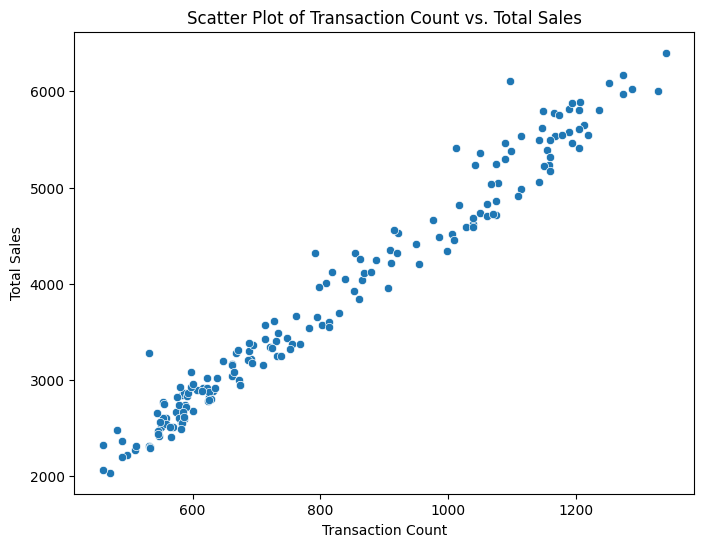

In [35]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='transaction_count', y='total_sales', data=daily_metrics)
plt.title('Scatter Plot of Transaction Count vs. Total Sales')
plt.xlabel('Transaction Count')
plt.ylabel('Total Sales')
plt.show()

### Relationship between transaction quantity and unit price

In [36]:
## Checking Their Correlation
sales_df[['transaction_qty', 'unit_price']].corr()

,transaction_qty,unit_price
transaction_qty,1.000000,-0.123494
unit_price,-0.123494,1.000000


### Interpretation of the Correlation

The correlation between **transaction quantity (`transaction_qty`)** and **unit price (`unit_price`)** is **-0.123**.

**What this means:**

- The correlation is **negative**, meaning that as the **unit price increases, the transaction quantity tends to slightly decrease**, and vice versa.
- However, the value **-0.123 is very close to 0**, which indicates a **very weak relationship**.
- This suggests that **unit price does not strongly influence how many items are purchased per transaction**.

**Conclusion:**  
There is **little to no linear relationship** between transaction quantity and unit price.

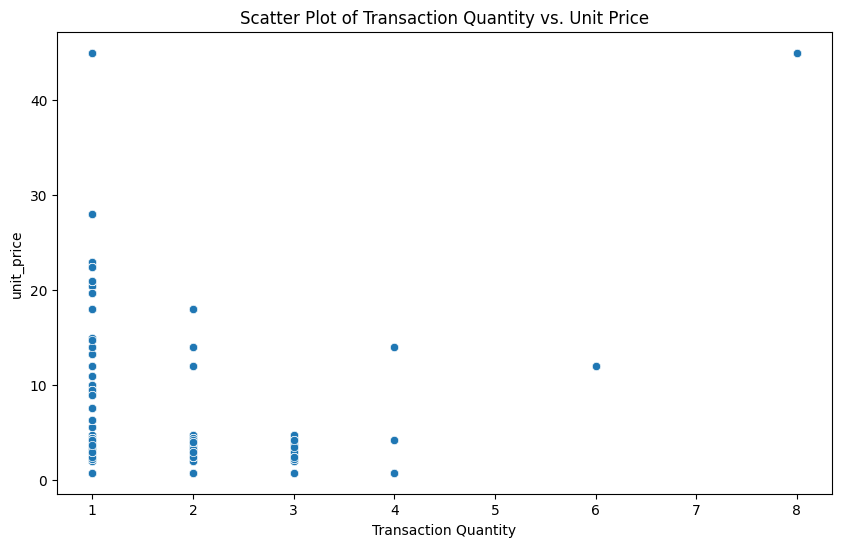

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='transaction_qty', y='unit_price', data=sales_df)
plt.title('Scatter Plot of Transaction Quantity vs. Unit Price')
plt.xlabel('Transaction Quantity')
plt.show()

### Critical Thinking Question 3 Interpretation

Negative correlation between the **average transaction value** and the **number of transactions per day** does not automatically mean that having more customers causes each customer to spend less. Correlation shows an association, but it does not prove the reason behind it.

#### **Possible Explanations**

There are several possible explanations for this relationship in Transactions:

- **Product mix:** On busy days, customers may buy more low-priced items, which increases the number of transactions but lowers the average transaction value.
- **Store differences:** Some store locations may naturally have higher traffic but lower-value purchases, while others may have fewer transactions but higher-value sales.
- **Time patterns:** Certain days of the week, months, or hours may attract more customers making quick purchases rather than larger ones.

#### Additional Analysis Needed

*Before making strategic recommendations We Compared by store location to see whether the pattern is the same across all stores.*

**Below Analysis coould Also be done on the same**.

- **Compare by product category or product type** to check whether certain products drive the relationship.
- **Analyze by day of week, month, and hour** to identify whether the pattern is linked to timing.
- **Check for outliers** to see whether a few unusually large transactions are affecting the average.

These steps would help determine whether the negative correlation reflects real customer behavior or whether it is influenced by store, product, or time-related factors.

#### Comparision By Store Location

In [38]:
daily_store_metrics = sales_df.groupby(
    [sales_df['transaction_datetime'].dt.date, 'store_location']
).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

daily_store_corr = daily_store_metrics.groupby('store_location')[['transaction_count', 'avg_transaction_value']].corr().reset_index()
store_corrs = daily_store_metrics.groupby('store_location').apply(
    lambda x: x['transaction_count'].corr(x['avg_transaction_value'])
).reset_index(name='corr_transaction_vs_atv')

store_corrs

/tmp/ipykernel_369/4216404295.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_corrs = daily_store_metrics.groupby('store_location').apply(


,store_location,corr_transaction_vs_atv
0,Astoria,-0.016182
1,Hell's Kitchen,-0.060180
2,Lower Manhattan,0.069405


#### Conclusion

The correlation between **transaction quantity and average transaction value (ATV)** is **very close to zero for all store locations**.

- **Astoria (-0.016)** → Almost no relationship.
- **Hell's Kitchen (-0.060)** → Very weak negative relationship.
- **Lower Manhattan (0.069)** → Very weak positive relationship.

**Overall Interpretation:**

The number of items purchased in a transaction **does not significantly influence the average transaction value across the stores**.  
This suggests that other factors (such as product type, pricing strategy, or promotions) may have a stronger impact on ATV than transaction quantity.

## Task 3.2: Categorical Relationships

To analyze relationships involving categorical variables:

**Required Visualizations:**
1. Box plots comparing transaction amounts across different product categories
2. Bar chart showing total sales by day of week
3. Heatmap showing sales patterns by hour and day of week
4. Compare average transaction values across different store locations

### Box plots To compare transaction amounts across different product categories

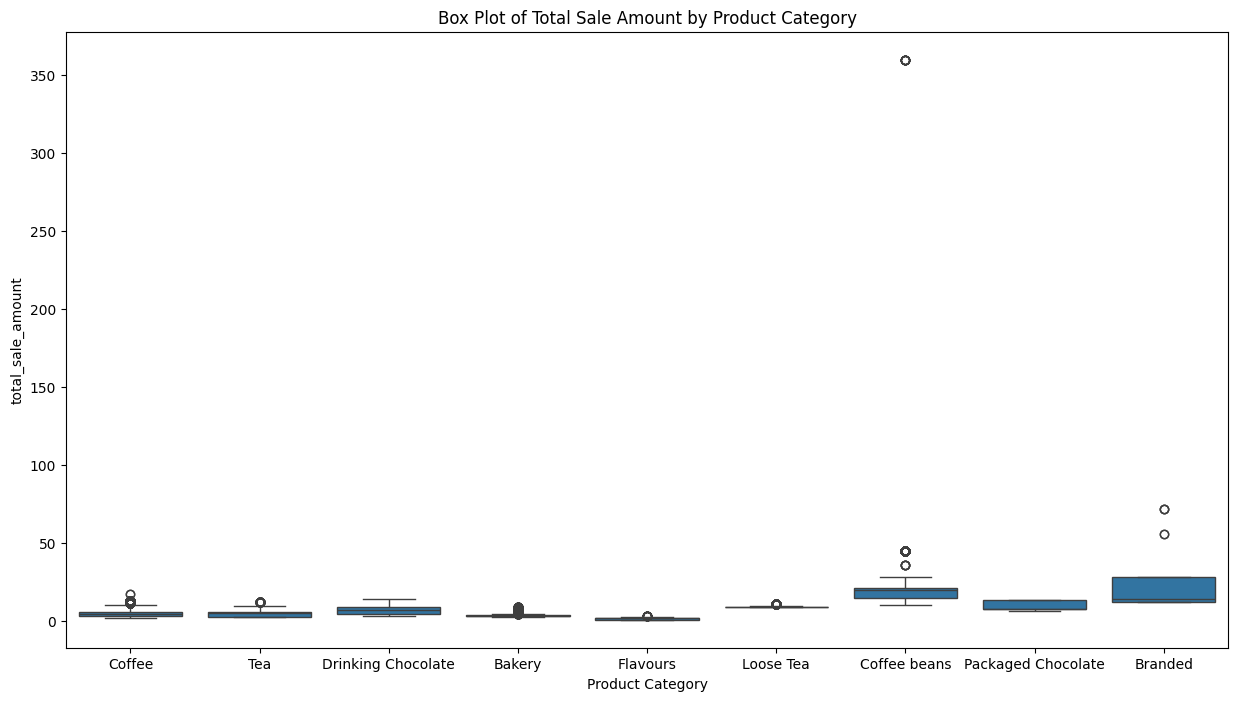

In [41]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='product_category', y='total_sale_amount', data=sales_df)
plt.title('Box Plot of Total Sale Amount by Product Category')
plt.xlabel('Product Category')
plt.show()

### Bar chart To show total sales by day of week

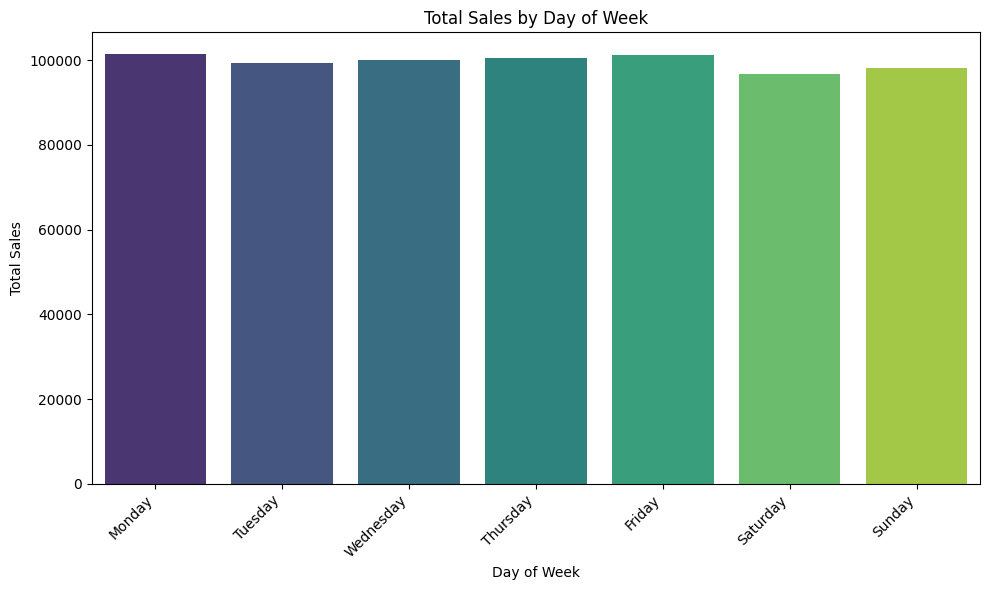

In [53]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
total_sales_by_day = sales_df.groupby('day_of_week')['total_sale_amount'].sum().reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=total_sales_by_day.index, y=total_sales_by_day.values, palette='viridis', hue=total_sales_by_day.index, legend=False)
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Heatmap showing sales patterns by hour and day of week

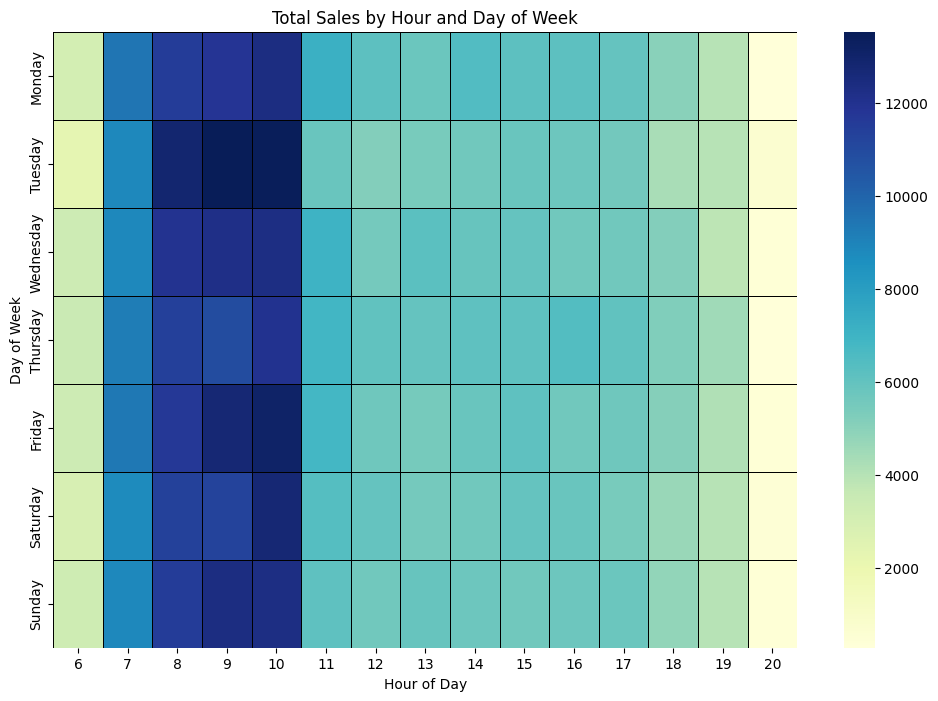

In [57]:
sales_heatmap_data = sales_df.groupby(['day_of_week', 'hour'])['total_sale_amount'].sum().unstack()

# Ensure the days of the week are in order for plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_heatmap_data = sales_heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 8))
sns.heatmap(sales_heatmap_data, cmap='YlGnBu', fmt='.0f', linewidths=.5, linecolor='black')
plt.title('Total Sales by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

### Comparing average transaction values across different store locations

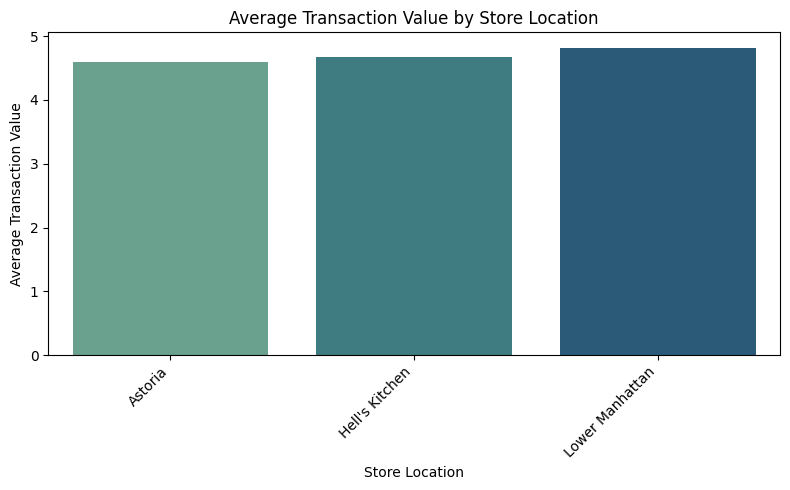

In [68]:
store_location_atv = sales_df.groupby('store_location').agg(
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='store_location', y='avg_transaction_value', data=store_location_atv, palette='crest', hue='store_location', legend=False)
plt.xlabel('Store Location')
plt.ylabel('Average Transaction Value')
plt.title('Average Transaction Value by Store Location')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Developing and Testing Hypothisis to Explain Why Weekend Sales Might Be lower than WeekDays

#### Hypothesis 1: Customer Behavior
**Hypothesis:**  
Weekend customers make smaller purchases, resulting in a lower **average transaction value (ATV)** compared to weekdays.

In [80]:
# Creating a copy of new Sales Dataframe for This analysis
analysis_df = sales_df.copy()

# Creating Weekend/Weekday Column
analysis_df['day_type'] = sales_df['day_of_week'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

# analysis_df.day_type.unique()

customer_behavior = analysis_df.groupby('day_type').agg(
    avg_transaction_value=('total_sale_amount', 'mean'),
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count')
).reset_index()
customer_behavior

,day_type,avg_transaction_value,total_sales,transaction_count
0,Weekday,4.687075,502520.09,107214
1,Weekend,4.694827,194854.09,41504


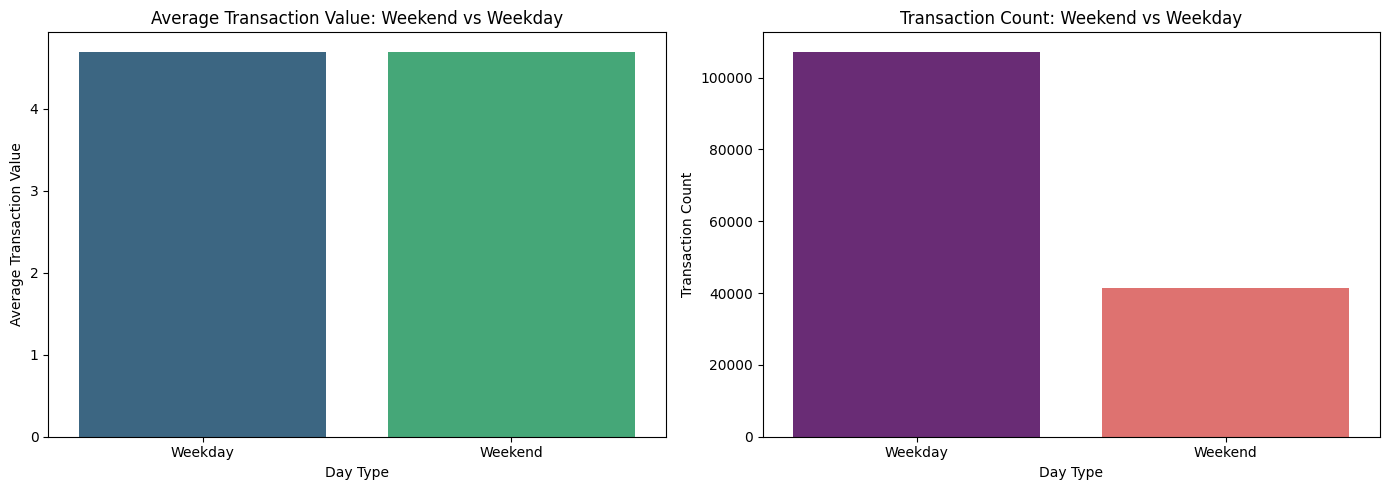

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for Average Transaction Value
sns.barplot(x='day_type', y='avg_transaction_value', data=customer_behavior, ax=axes[0], palette='viridis', hue='day_type', legend=False)
axes[0].set_title('Average Transaction Value: Weekend vs Weekday')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Average Transaction Value')

# Plot for Transaction Count
sns.barplot(x='day_type', y='transaction_count', data=customer_behavior, ax=axes[1], palette='magma', hue='day_type', legend=False)
axes[1].set_title('Transaction Count: Weekend vs Weekday')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.show()

##### Findings
Customer analysis suggests that the lower weekend sales are not mainly caused by customers spending less per transaction.

The average transaction value (ATV) is almost the same on weekdays and weekends, which means customer spending per purchase remains fairly consistent.

This does not support the idea that weekend customers make smaller purchases.

#### Hypothesis 2: Product Mix
**Hypothesis:**  
Weekends may have a different **product mix**, with more sales coming from cheaper product categories or product types.

In [92]:
## Checking Product Category
category_mix = analysis_df.groupby(['day_type', 'product_category']).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_price=('unit_price', 'mean'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

category_mix.sort_values(['day_type', 'total_sales'], ascending=[True, False]).head(20)

,day_type,product_category,total_sales,transaction_count,avg_price,avg_transaction_value
2,Weekday,Coffee,194349.35,42052,3.022919,4.621643
8,Weekday,Tea,141872.25,32785,2.818777,4.327352
0,Weekday,Bakery,58783.84,16274,3.550549,3.612132
4,Weekday,Drinking Chocolate,52188.50,8252,4.149085,6.324346
3,Weekday,Coffee beans,28540.15,1253,20.974581,22.777454
1,Weekday,Branded,9566.00,527,17.586338,18.151803
6,Weekday,Loose Tea,8093.15,873,9.270504,9.270504
5,Weekday,Flavours,6006.40,4853,0.800000,1.237667
7,Weekday,Packaged Chocolate,3120.45,345,9.044783,9.044783
11,Weekend,Coffee,75241.45,16254,3.023739,4.629104


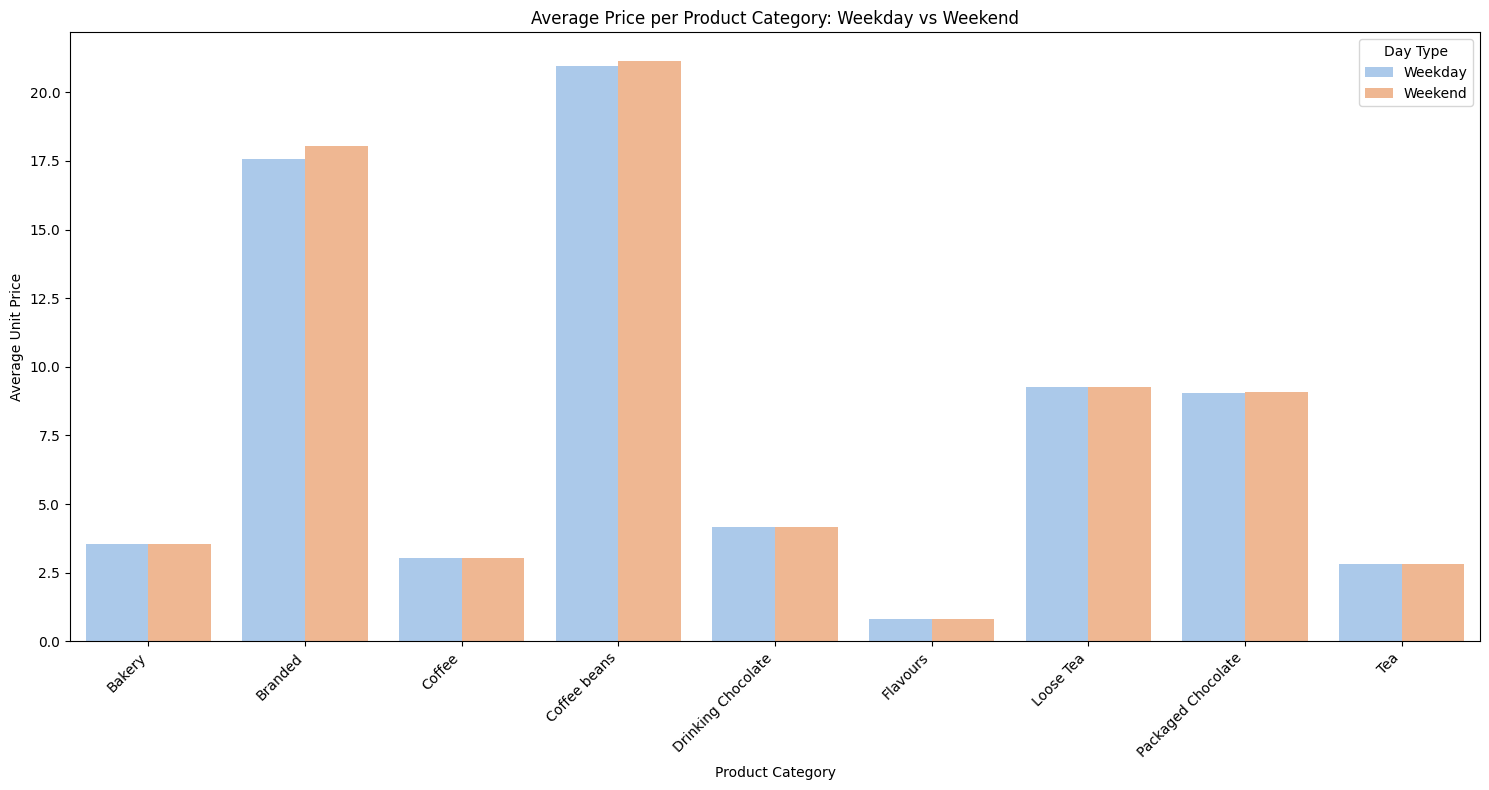

In [93]:
## Visualizing Average Price per Product Category: Weekday vs Weekend
plt.figure(figsize=(15, 8))
sns.barplot(x='product_category', y='avg_price', hue='day_type', data=category_mix, palette='pastel')
plt.title('Average Price per Product Category: Weekday vs Weekend')
plt.xlabel('Product Category')
plt.ylabel('Average Unit Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

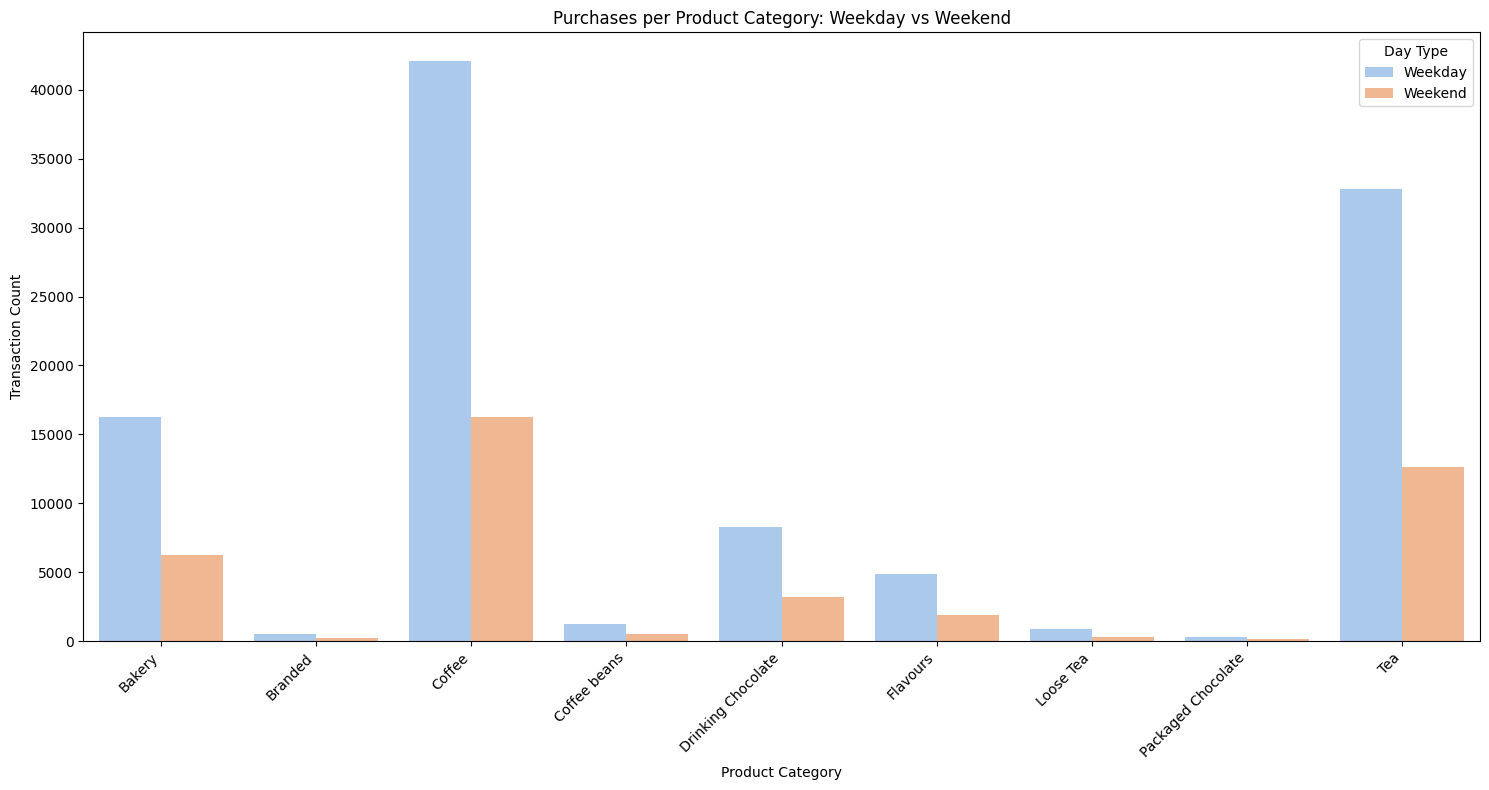

In [94]:
## Visualizing Purchases per Product Category: Weekday vs Weekend
plt.figure(figsize=(15, 8))
sns.barplot(x='product_category', y='transaction_count', hue='day_type', data=category_mix, palette='pastel')
plt.title('Purchases per Product Category: Weekday vs Weekend')
plt.xlabel('Product Category')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

##### Findings
From Product Mix Analysis, We See that, Although the average prices across product categories are similar on weekdays and weekends,

key categories such as `Coffee`, `Bakery`, and `Tea` have noticeably higher transaction counts on weekdays.

This means that weekday sales are stronger because these popular categories are purchased more often during the week.

#### Hypothesis 3: Location characteristics
**Hypothesis:**  
Some **store locations perform significantly worse on weekends**, which lowers total weekend sales.

In [96]:
location_analysis = analysis_df.groupby(['day_type', 'store_location']).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

location_analysis.sort_values(['store_location', 'day_type'])

,day_type,store_location,total_sales,transaction_count,avg_transaction_value
0,Weekday,Astoria,167179.90,36467,4.584416
3,Weekend,Astoria,64532.41,13985,4.614402
1,Weekday,Hell's Kitchen,169878.01,36444,4.661344
4,Weekend,Hell's Kitchen,66151.11,14152,4.674329
2,Weekday,Lower Manhattan,165462.18,34303,4.823548
5,Weekend,Lower Manhattan,64170.57,13367,4.800671


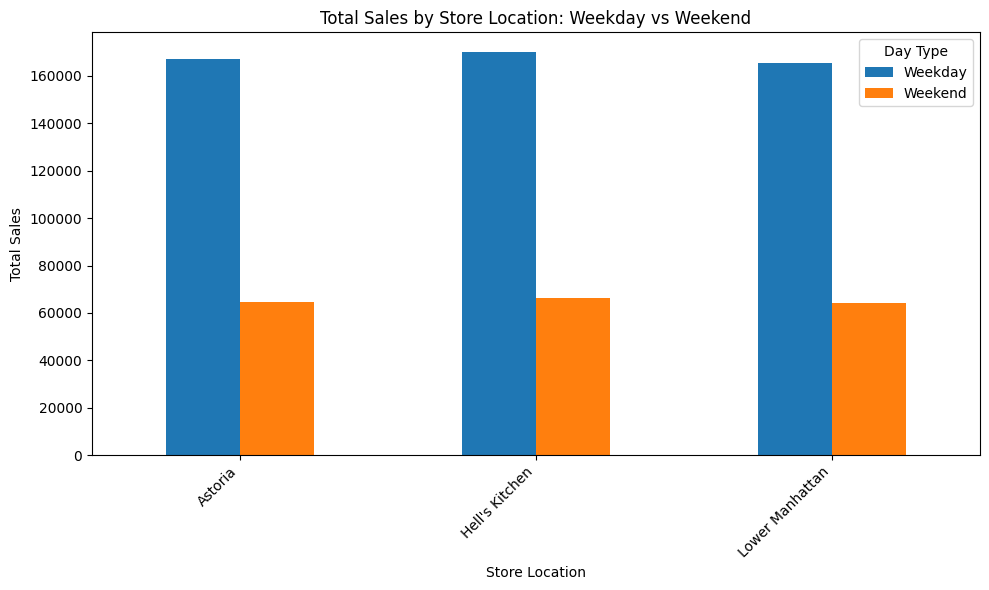

In [98]:
location_pivot = location_analysis.pivot(
    index='store_location',
    columns='day_type',
    values='total_sales'
)

# Plotting the data
location_pivot.plot(kind='bar', figsize=(10, 6))
plt.title('Total Sales by Store Location: Weekday vs Weekend')
plt.xlabel('Store Location')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

##### Findings
store location analysis shows that all store locations experienced a similar drop in sales on weekends. This suggests that the weekend decline is not being caused by one weak store,

#### Hypothesis 4: Timing Patterns

**Hypothesis:**  
Weekend hourly sales patterns may be shorter or weaker compared to weekday peak hours.

In [100]:
hourly_analysis = analysis_df.groupby(['day_type', 'hour']).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

hourly_analysis.head()

,day_type,hour,total_sales,transaction_count,avg_transaction_value
0,Weekday,6,15628.19,3276,4.770510
1,Weekday,7,45741.36,9629,4.750375
2,Weekday,8,59488.17,12677,4.692606
3,Weekday,9,61205.28,12786,4.786898
4,Weekday,10,63276.16,13310,4.754032


In [101]:
hourly_sales_pivot = hourly_analysis.pivot(
    index='hour',
    columns='day_type',
    values='total_sales'
)

hourly_sales_pivot

day_type,Weekday,Weekend
hour,,
6,15628.19,6223.33
7,45741.36,17607.76
8,59488.17,22895.65
9,61205.28,23634.15
10,63276.16,25026.23
11,33788.49,12477.15
12,28579.20,11570.64
13,28909.82,11457.63
14,29904.33,11390.06


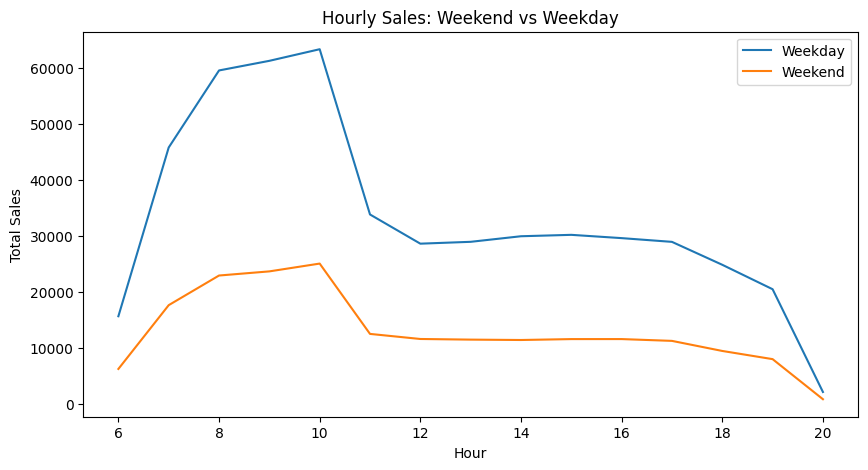

In [102]:
weekday_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekday']
weekend_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekend']

plt.figure(figsize=(10,5))
plt.plot(weekday_hourly['hour'], weekday_hourly['total_sales'], label='Weekday')
plt.plot(weekend_hourly['hour'], weekend_hourly['total_sales'], label='Weekend')
plt.xlabel('Hour')
plt.ylabel('Total Sales')
plt.title('Hourly Sales: Weekend vs Weekday')
plt.legend()
plt.show()

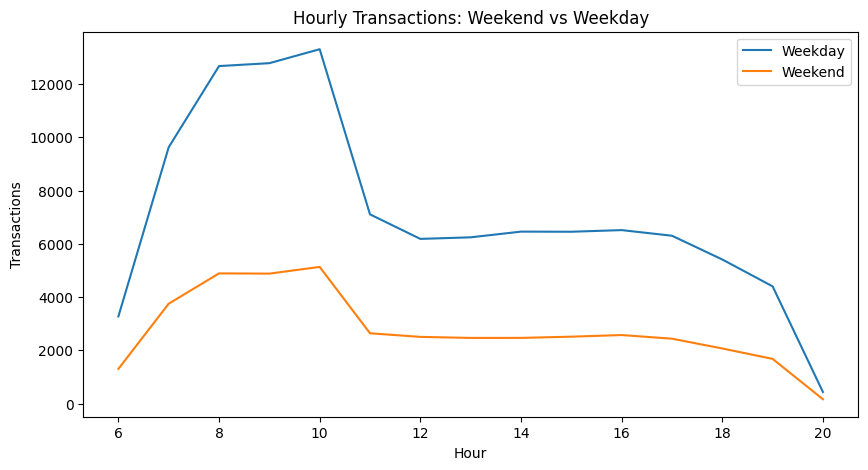

In [106]:
weekday_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekday']
weekend_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekend']

plt.figure(figsize=(10,5))
plt.plot(weekday_hourly['hour'], weekday_hourly['transaction_count'], label='Weekday')
plt.plot(weekend_hourly['hour'], weekend_hourly['transaction_count'], label='Weekend')
plt.xlabel('Hour')
plt.ylabel('Transactions')
plt.title('Hourly Transactions: Weekend vs Weekday')
plt.legend()
plt.show()

In [104]:
overall_daytype = analysis_df.groupby('day_type').agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

overall_daytype

,day_type,total_sales,transaction_count,avg_transaction_value
0,Weekday,502520.09,107214,4.687075
1,Weekend,194854.09,41504,4.694827


##### Findings
hourly analysis shows that weekend hourly sales patterns are similar, which suggests that timing is also not a strong explanation for the lower weekend sales.

#### Conclusion
The results instead suggest that the main reason for lower weekend sales is **`lower transaction volume`**. Although the average prices across product categories are similar on weekdays and weekends,

key categories such as **`Coffee`, `Bakery`, and `Tea`** have noticeably higher transaction counts on weekdays. This means that weekday sales are stronger because these popular categories are purchased more often during the week.

Results shows That any strategies to boost weekend sales should focus on increasing transaction count, rather than altering product pricing, mix, or specific store
operations based on perceived differences in customer behavior.